<a href="https://colab.research.google.com/github/Alejandra300905/german-credit-risk-classification/blob/main/German_Credit_Risk_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# GERMAN CREDIT DATA — Clasificación

Dataset: https://archive.ics.uci.edu/dataset/144/statlog+german+credit+data


In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Datos

In [2]:
import pandas as pd

url = '/content/drive/MyDrive/MachineLearning/ProyectoAleClasificacion/statlog+german+credit+data/german.data-numeric'

df = pd.read_csv(
    url,
    sep=r'\s+',
    header=None,
    engine='python'
)

print(df.shape)
df.head()

(1000, 25)


,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
0,1,6,4,12,5,5,3,4,1,67,...,0,0,1,0,0,1,0,0,1,1
1,2,48,2,60,1,3,2,2,1,22,...,0,0,1,0,0,1,0,0,1,2
2,4,12,4,21,1,4,3,3,1,49,...,0,0,1,0,0,1,0,1,0,1
3,1,42,2,79,1,4,3,4,2,45,...,0,0,0,0,0,0,0,0,1,1
4,1,24,3,49,1,3,3,4,4,53,...,1,0,1,0,0,0,0,0,1,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 25 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   0       1000 non-null   int64
 1   1       1000 non-null   int64
 2   2       1000 non-null   int64
 3   3       1000 non-null   int64
 4   4       1000 non-null   int64
 5   5       1000 non-null   int64
 6   6       1000 non-null   int64
 7   7       1000 non-null   int64
 8   8       1000 non-null   int64
 9   9       1000 non-null   int64
 10  10      1000 non-null   int64
 11  11      1000 non-null   int64
 12  12      1000 non-null   int64
 13  13      1000 non-null   int64
 14  14      1000 non-null   int64
 15  15      1000 non-null   int64
 16  16      1000 non-null   int64
 17  17      1000 non-null   int64
 18  18      1000 non-null   int64
 19  19      1000 non-null   int64
 20  20      1000 non-null   int64
 21  21      1000 non-null   int64
 22  22      1000 non-null   int64
 23  23      1000 n

In [4]:
df.describe()

,0,1,2,3,4,5,6,7,8,9,...,15,16,17,18,19,20,21,22,23,24
count,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,...,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.0000,1000.000000,1000.000000
mean,2.577000,20.903000,2.54500,32.711000,2.105000,3.384000,2.68200,2.845000,2.358000,35.546000,...,0.234000,0.103000,0.907000,0.041000,0.179000,0.713000,0.022000,0.2000,0.630000,1.300000
std,1.257638,12.058814,1.08312,28.252605,1.580023,1.208306,0.70808,1.103718,1.050209,11.375469,...,0.423584,0.304111,0.290578,0.198389,0.383544,0.452588,0.146757,0.4002,0.483046,0.458487
min,1.000000,4.000000,0.00000,2.000000,1.000000,1.000000,1.00000,1.000000,1.000000,19.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
25%,1.000000,12.000000,2.00000,14.000000,1.000000,3.000000,2.00000,2.000000,1.000000,27.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.0000,0.000000,1.000000
50%,2.000000,18.000000,2.00000,23.000000,1.000000,3.000000,3.00000,3.000000,2.000000,33.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,1.000000
75%,4.000000,24.000000,4.00000,40.000000,3.000000,5.000000,3.00000,4.000000,3.000000,42.000000,...,0.000000,0.000000,1.000000,0.000000,0.000000,1.000000,0.000000,0.0000,1.000000,2.000000
max,4.000000,72.000000,4.00000,184.000000,5.000000,5.000000,4.00000,4.000000,4.000000,75.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0000,1.000000,2.000000


## Distribución de los datos

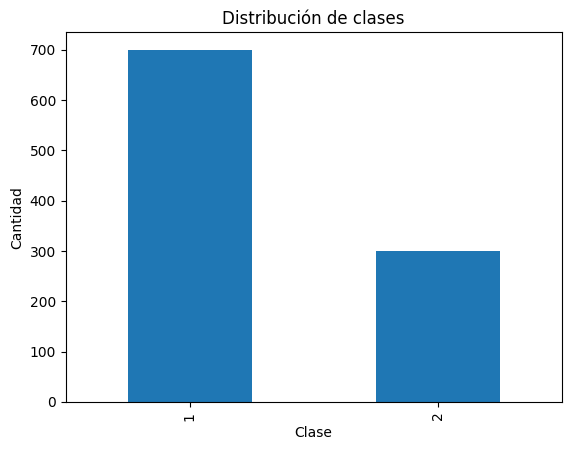

In [5]:
import matplotlib.pyplot as plt
df[24].value_counts().plot(kind='bar')
plt.title('Distribución de clases')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.show()

## Target

In [6]:
y = df.iloc[:, -1]
print(y.value_counts())

y = y.replace({
    1: 0,
    2: 1
})

24
1    700
2    300
Name: count, dtype: int64


## Separación entre características y target

In [7]:
X = df.iloc[:, :-1]
print(X.shape)
print(y.shape)

(1000, 24)
(1000,)


## Datos para entrenamiento y prueba

El test se separa **antes** de cualquier ajuste/escalado. `stratify=y` mantiene la proporción de clases (el dataset está desbalanceado).

In [8]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Escalado (nota importante)

Ya **no** se hace un escalado global aquí. El escalado se realiza **dentro de cada Pipeline** (Logistic y SVM) para que el `StandardScaler` se ajuste solo con datos de entrenamiento y se reajuste en cada fold del cross-validation. Esto evita el **Data Leakage**. Decision Tree y Random Forest no requieren escalado.

In [9]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

## Regresión logística

In [10]:
# Entrenamiento del modelo (escalado dentro del Pipeline)
from sklearn.linear_model import LogisticRegression

model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=2000))
])

model.fit(X_train, y_train)

train_accuracy = model.score(X_train, y_train)
print("Training Accuracy:", train_accuracy)

test_accuracy = model.score(X_test, y_test)
print("Test Accuracy:", test_accuracy)

Training Accuracy: 0.78
Test Accuracy: 0.77


[[125  15]
 [ 31  29]]


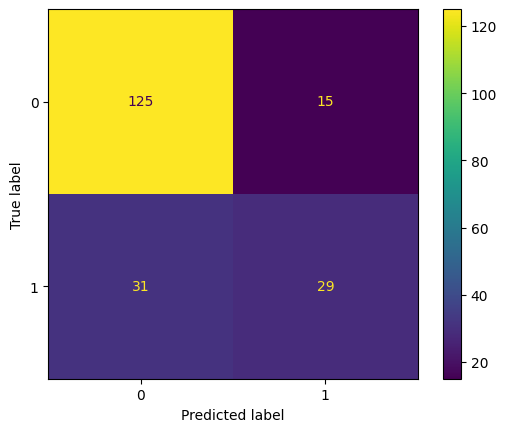

In [11]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

y_pred = model.predict(X_test)

cm = confusion_matrix(y_test, y_pred)
print(cm)

disp = ConfusionMatrixDisplay(cm)
disp.plot()

## Curva ROC para regresión logística

AUC: 0.82


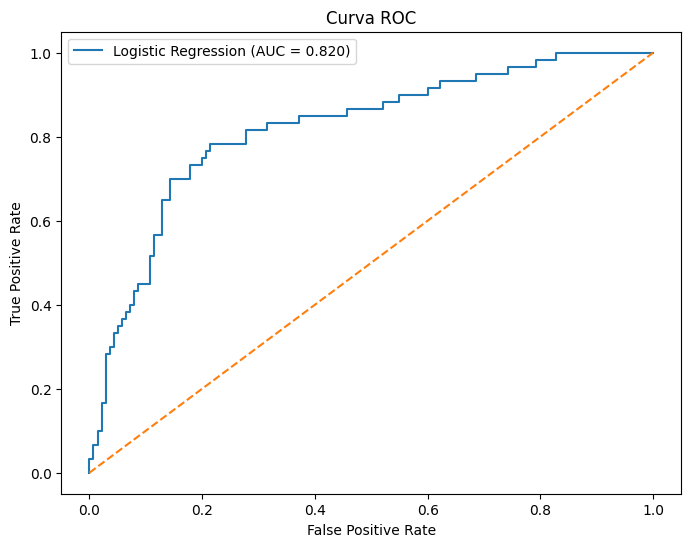

In [12]:
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import matplotlib.pyplot as plt

# Probabilidades de la clase positiva (Bad Credit = 1)
y_prob = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)
print("AUC:", auc)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.show()

In [13]:
from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.89      0.84       140
           1       0.66      0.48      0.56        60

    accuracy                           0.77       200
   macro avg       0.73      0.69      0.70       200
weighted avg       0.76      0.77      0.76       200



## Comparación con otros modelos

### Árbol de decisión (sin escalado)

[[110  30]
 [ 26  34]]


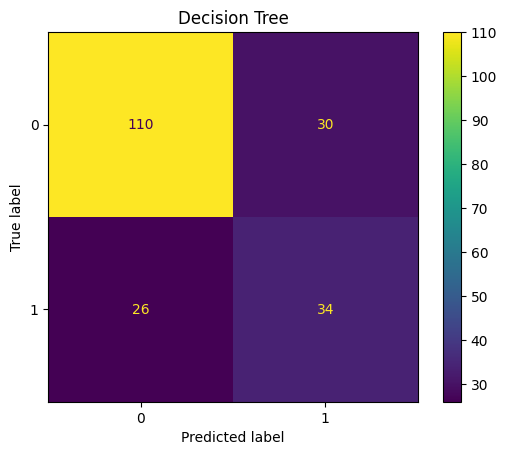

Decision Tree AUC: 0.6761904761904762


In [14]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)

tree_pred = tree_model.predict(X_test)

cm_tree = confusion_matrix(y_test, tree_pred)
print(cm_tree)

ConfusionMatrixDisplay(cm_tree).plot()
plt.title("Decision Tree")
plt.show()

tree_prob = tree_model.predict_proba(X_test)[:, 1]
tree_auc = roc_auc_score(y_test, tree_prob)
print("Decision Tree AUC:", tree_auc)

### Random Forest (sin escalado: es invariante a la escala)

[[129  11]
 [ 31  29]]


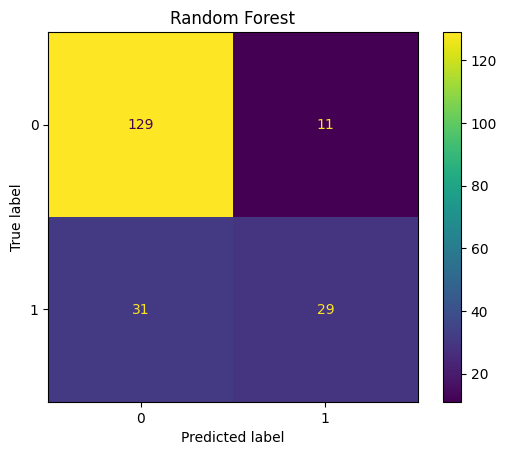

Random Forest AUC: 0.7928571428571429


In [15]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

cm_rf = confusion_matrix(y_test, rf_pred)
print(cm_rf)

ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest")
plt.show()

rf_prob = rf_model.predict_proba(X_test)[:, 1]
rf_auc = roc_auc_score(y_test, rf_prob)
print("Random Forest AUC:", rf_auc)

### SVM (escalado dentro del Pipeline)

[[127  13]
 [ 38  22]]


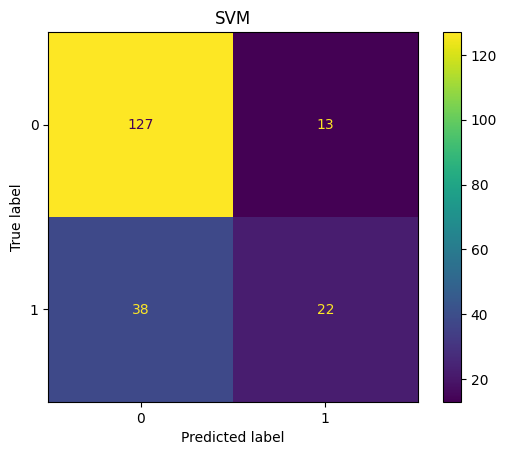

SVM AUC: 0.7888095238095238


In [16]:
from sklearn.svm import SVC

svm_model = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel='rbf', probability=True, random_state=42))
])

svm_model.fit(X_train, y_train)

svm_pred = svm_model.predict(X_test)

cm_svm = confusion_matrix(y_test, svm_pred)
print(cm_svm)

ConfusionMatrixDisplay(cm_svm).plot()
plt.title("SVM")
plt.show()

svm_prob = svm_model.predict_proba(X_test)[:, 1]
svm_auc = roc_auc_score(y_test, svm_prob)
print("SVM AUC:", svm_auc)

## Comparación final

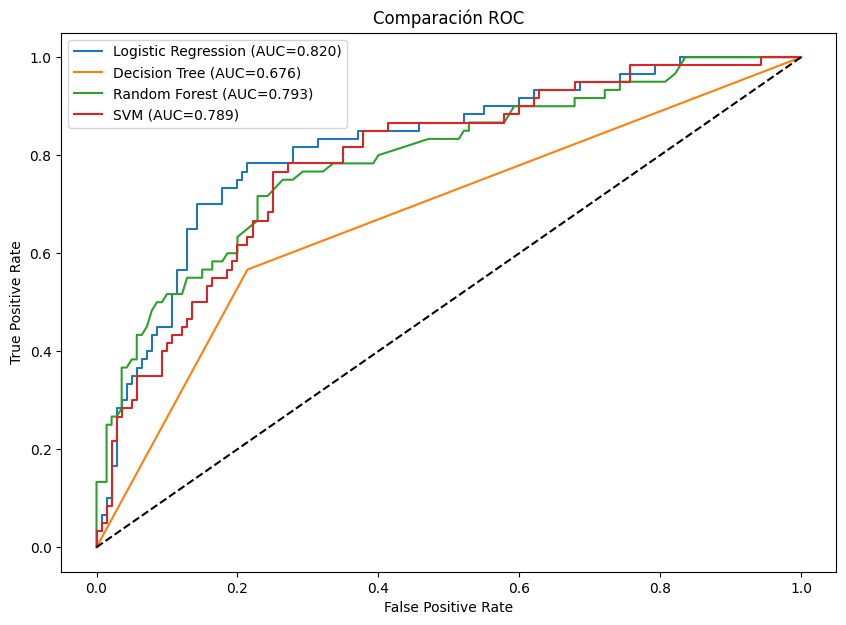

In [17]:
from sklearn.metrics import roc_curve

plt.figure(figsize=(10, 7))

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
fpr_tree, tpr_tree, _ = roc_curve(y_test, tree_prob)
fpr_rf, tpr_rf, _ = roc_curve(y_test, rf_prob)
fpr_svm, tpr_svm, _ = roc_curve(y_test, svm_prob)

plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc:.3f})')
plt.plot(fpr_tree, tpr_tree, label=f'Decision Tree (AUC={tree_auc:.3f})')
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={rf_auc:.3f})')
plt.plot(fpr_svm, tpr_svm, label=f'SVM (AUC={svm_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Comparación ROC")
plt.legend()
plt.show()

In [18]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

results = pd.DataFrame({
    "Modelo": ["Logistic Regression", "Decision Tree", "Random Forest", "SVM"],
    "Accuracy": [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, tree_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, svm_pred)
    ],
    "Precision": [
        precision_score(y_test, y_pred),
        precision_score(y_test, tree_pred),
        precision_score(y_test, rf_pred),
        precision_score(y_test, svm_pred)
    ],
    "Recall": [
        recall_score(y_test, y_pred),
        recall_score(y_test, tree_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, svm_pred)
    ],
    "F1": [
        f1_score(y_test, y_pred),
        f1_score(y_test, tree_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, svm_pred)
    ],
    "AUC": [auc, tree_auc, rf_auc, svm_auc]
})

print(results)

                Modelo  Accuracy  Precision    Recall        F1       AUC
0  Logistic Regression     0.770   0.659091  0.483333  0.557692  0.820000
1        Decision Tree     0.720   0.531250  0.566667  0.548387  0.676190
2        Random Forest     0.790   0.725000  0.483333  0.580000  0.792857
3                  SVM     0.745   0.628571  0.366667  0.463158  0.788810


## Mejora con Cross-Validation y GridSearchCV

**Nota anti-leakage:** Logistic y SVM optimizan dentro de un `Pipeline` con `StandardScaler`, así el escalado se reajusta en cada fold del CV. Tree y RF se optimizan con `X_train` crudo. En **todos** los casos se pasa `X_train` crudo a `GridSearchCV` (nunca datos pre-escalados).

In [19]:
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

scoring = {
    "Accuracy": "accuracy",
    "Recall": "recall",
    "F1": "f1",
    "AUC": "roc_auc"
}

In [20]:
# Regresión logística optimizada
pipe_log = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=3000, random_state=42))
])

param_log = {
    "model__C": [0.01, 0.1, 1, 10, 100],
    "model__class_weight": [None, "balanced"]
}

grid_log = GridSearchCV(pipe_log, param_log, cv=5, scoring=scoring, refit="AUC", n_jobs=-1)
grid_log.fit(X_train, y_train)

print("Mejores parámetros Logistic Regression:")
print(grid_log.best_params_)
print("Mejor AUC CV:", grid_log.best_score_)

Mejores parámetros Logistic Regression:
{'model__C': 0.01, 'model__class_weight': 'balanced'}
Mejor AUC CV: 0.7860491071428573


In [21]:
# Árbol de decisión optimizado (sin escalado)
tree_opt = DecisionTreeClassifier(random_state=42)

param_tree = {
    "max_depth": [2, 3, 4, 5, 6, 8, 10, None],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 5, 10],
    "class_weight": [None, "balanced"]
}

grid_tree = GridSearchCV(tree_opt, param_tree, cv=5, scoring=scoring, refit="AUC", n_jobs=-1)
grid_tree.fit(X_train, y_train)

print("Mejores parámetros Decision Tree:")
print(grid_tree.best_params_)
print("Mejor AUC CV:", grid_tree.best_score_)

Mejores parámetros Decision Tree:
{'class_weight': 'balanced', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 20}
Mejor AUC CV: 0.7250744047619048


In [22]:
# Random Forest optimizado (sin escalado)
rf_opt = RandomForestClassifier(random_state=42)

param_rf = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 8, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 5],
    "class_weight": [None, "balanced"]
}

grid_rf = GridSearchCV(rf_opt, param_rf, cv=5, scoring=scoring, refit="AUC", n_jobs=-1)
grid_rf.fit(X_train, y_train)

print("Mejores parámetros Random Forest:")
print(grid_rf.best_params_)
print("Mejor AUC CV:", grid_rf.best_score_)

Mejores parámetros Random Forest:
{'class_weight': None, 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Mejor AUC CV: 0.7978794642857142


In [23]:
# SVM optimizado
pipe_svm = Pipeline([
    ("scaler", StandardScaler()),
    ("model", SVC(kernel="rbf", probability=True, random_state=42))
])

param_svm = {
    "model__C": [0.1, 1, 10, 100],
    "model__gamma": ["scale", 0.001, 0.01, 0.1, 1],
    "model__class_weight": [None, "balanced"]
}

grid_svm = GridSearchCV(pipe_svm, param_svm, cv=5, scoring=scoring, refit="AUC", n_jobs=-1)
grid_svm.fit(X_train, y_train)

print("Mejores parámetros SVM:")
print(grid_svm.best_params_)
print("Mejor AUC CV:", grid_svm.best_score_)

Mejores parámetros SVM:
{'model__C': 1, 'model__class_weight': 'balanced', 'model__gamma': 0.01}
Mejor AUC CV: 0.7906622023809524


## Evaluación final de modelos optimizados

Se evalúa sobre `X_test` crudo; cada `best_estimator_` aplica su propio escalado interno cuando corresponde.

In [24]:
best_models = {
    "Logistic Regression Optimizada": grid_log.best_estimator_,
    "Decision Tree Optimizado": grid_tree.best_estimator_,
    "Random Forest Optimizado": grid_rf.best_estimator_,
    "SVM Optimizado": grid_svm.best_estimator_
}

optimized_results = []

for name, model_opt in best_models.items():
    y_pred_opt = model_opt.predict(X_test)
    y_prob_opt = model_opt.predict_proba(X_test)[:, 1]

    optimized_results.append({
        "Modelo": name,
        "Accuracy": accuracy_score(y_test, y_pred_opt),
        "Precision": precision_score(y_test, y_pred_opt),
        "Recall": recall_score(y_test, y_pred_opt),
        "F1": f1_score(y_test, y_pred_opt),
        "AUC": roc_auc_score(y_test, y_prob_opt)
    })

results_optimized = pd.DataFrame(optimized_results)
print(results_optimized)

                           Modelo  Accuracy  Precision    Recall        F1  \
0  Logistic Regression Optimizada     0.760   0.571429  0.800000  0.666667   
1        Decision Tree Optimizado     0.685   0.483146  0.716667  0.577181   
2        Random Forest Optimizado     0.795   0.787879  0.433333  0.559140   
3                  SVM Optimizado     0.750   0.559524  0.783333  0.652778   

        AUC  
0  0.815595  
1  0.737321  
2  0.806429  
3  0.834286  


## Matrices de confusión — modelos optimizados


Logistic Regression Optimizada
[[104  36]
 [ 12  48]]


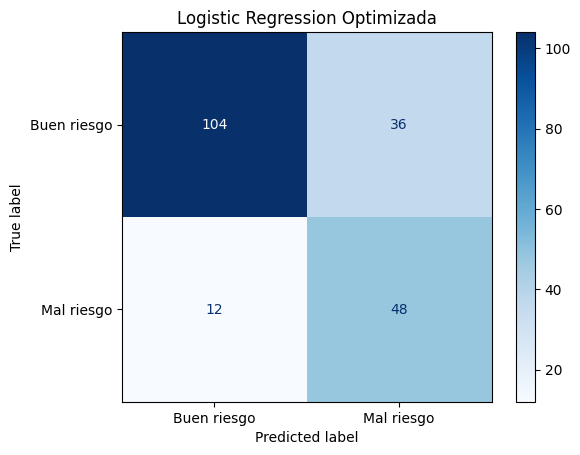


Decision Tree Optimizado
[[94 46]
 [17 43]]


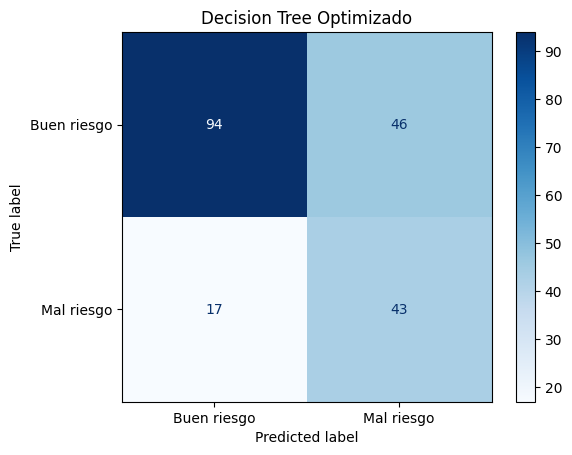


Random Forest Optimizado
[[133   7]
 [ 34  26]]


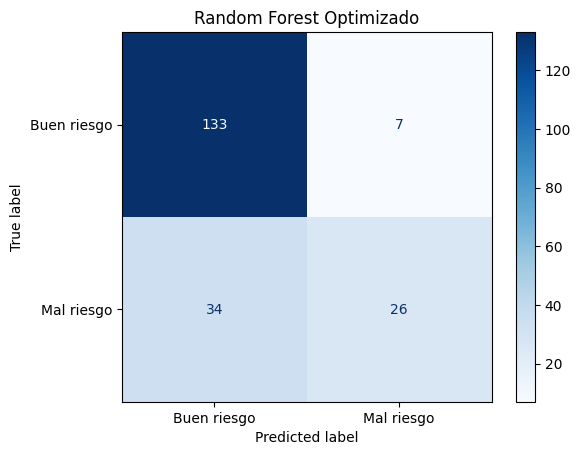


SVM Optimizado
[[103  37]
 [ 13  47]]


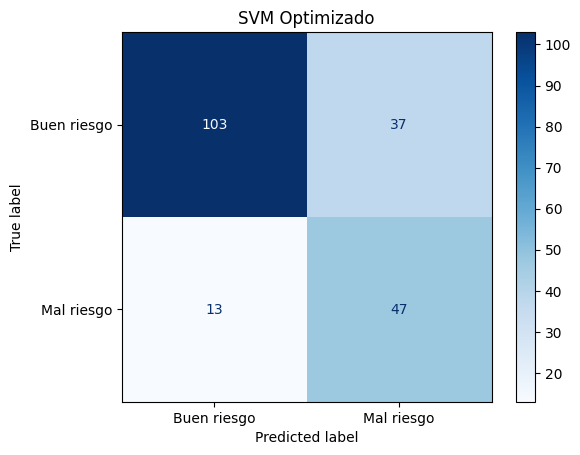

In [25]:
from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

for nombre, modelo in best_models.items():

    y_pred = modelo.predict(X_test)

    cm = confusion_matrix(y_test, y_pred)

    print(f"\n{nombre}")
    print(cm)

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Buen riesgo", "Mal riesgo"]
    )

    disp.plot(cmap="Blues")
    plt.title(nombre)
    plt.show()